In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [47]:
import pandas as pd

# Load the dataset
data = pd.read_csv('/workspaces/Heart-Attack-Predictor/notebooks/FC212041_Isivara/heart_attack_prediction.csv')

# Preview data
data.head()


,age,gender,region,income_level,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,...,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack
0,60,Male,Rural,Middle,0,1,211,0,83,0,...,62,173,48,121,101,Normal,0,0,0,0
1,53,Female,Urban,Low,0,0,208,0,106,1,...,76,70,58,83,138,Normal,1,0,1,0
2,62,Female,Urban,Low,0,0,231,1,112,1,...,74,118,69,130,171,Abnormal,0,1,0,1
3,73,Male,Urban,Low,1,0,202,0,82,1,...,65,98,52,85,146,Normal,0,1,1,0
4,52,Male,Urban,Middle,1,0,232,0,89,0,...,75,104,59,127,139,Normal,1,0,1,1


In [48]:
# Basic info
data.info()

# Check for missing values
print(data.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158355 entries, 0 to 158354
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   age                             158355 non-null  int64  
 1   gender                          158355 non-null  object 
 2   region                          158355 non-null  object 
 3   income_level                    158355 non-null  object 
 4   hypertension                    158355 non-null  int64  
 5   diabetes                        158355 non-null  int64  
 6   cholesterol_level               158355 non-null  int64  
 7   obesity                         158355 non-null  int64  
 8   waist_circumference             158355 non-null  int64  
 9   family_history                  158355 non-null  int64  
 10  smoking_status                  158355 non-null  object 
 11  alcohol_consumption             63507 non-null   object 
 12  physical_activit

In [49]:
# handel the missing values
data['alcohol_consumption'] = data['alcohol_consumption'].fillna("Unknown")
# check the missing values
data.isnull().sum()

age                               0
gender                            0
region                            0
income_level                      0
hypertension                      0
diabetes                          0
cholesterol_level                 0
obesity                           0
waist_circumference               0
family_history                    0
smoking_status                    0
alcohol_consumption               0
physical_activity                 0
dietary_habits                    0
air_pollution_exposure            0
stress_level                      0
sleep_hours                       0
blood_pressure_systolic           0
blood_pressure_diastolic          0
fasting_blood_sugar               0
cholesterol_hdl                   0
cholesterol_ldl                   0
triglycerides                     0
EKG_results                       0
previous_heart_disease            0
medication_usage                  0
participated_in_free_screening    0
heart_attack                

In [50]:
# check the duplicated values
data.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
158350    False
158351    False
158352    False
158353    False
158354    False
Length: 158355, dtype: bool

In [51]:
data.loc[data.duplicated()]

,age,gender,region,income_level,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,...,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack


Exploratory Data Analysis (EDA)

In [52]:
print(data.columns)

Index(['age', 'gender', 'region', 'income_level', 'hypertension', 'diabetes',
       'cholesterol_level', 'obesity', 'waist_circumference', 'family_history',
       'smoking_status', 'alcohol_consumption', 'physical_activity',
       'dietary_habits', 'air_pollution_exposure', 'stress_level',
       'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic',
       'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl',
       'triglycerides', 'EKG_results', 'previous_heart_disease',
       'medication_usage', 'participated_in_free_screening', 'heart_attack'],
      dtype='object')


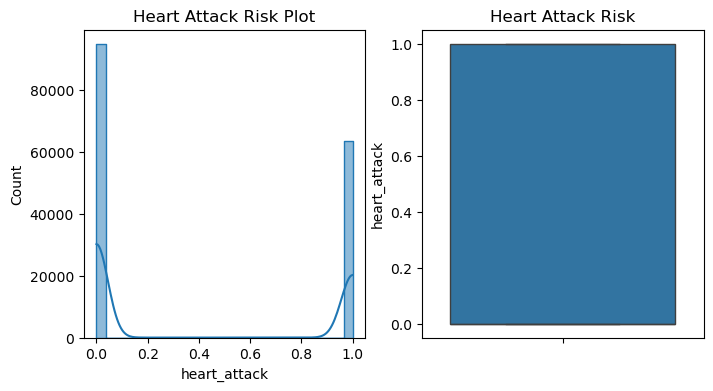

In [53]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title('Heart Attack Risk Plot')
sns.histplot(data["heart_attack"], kde=True, element='step')

plt.subplot(1,2,2)
sns.boxplot(data["heart_attack"])
plt.title('Heart Attack Risk')

plt.show()

In [54]:
categorical_features = [x for x in data.columns if data[x].dtype =='object']
categorical_features

['gender',
 'region',
 'income_level',
 'smoking_status',
 'alcohol_consumption',
 'physical_activity',
 'dietary_habits',
 'air_pollution_exposure',
 'stress_level',
 'EKG_results']

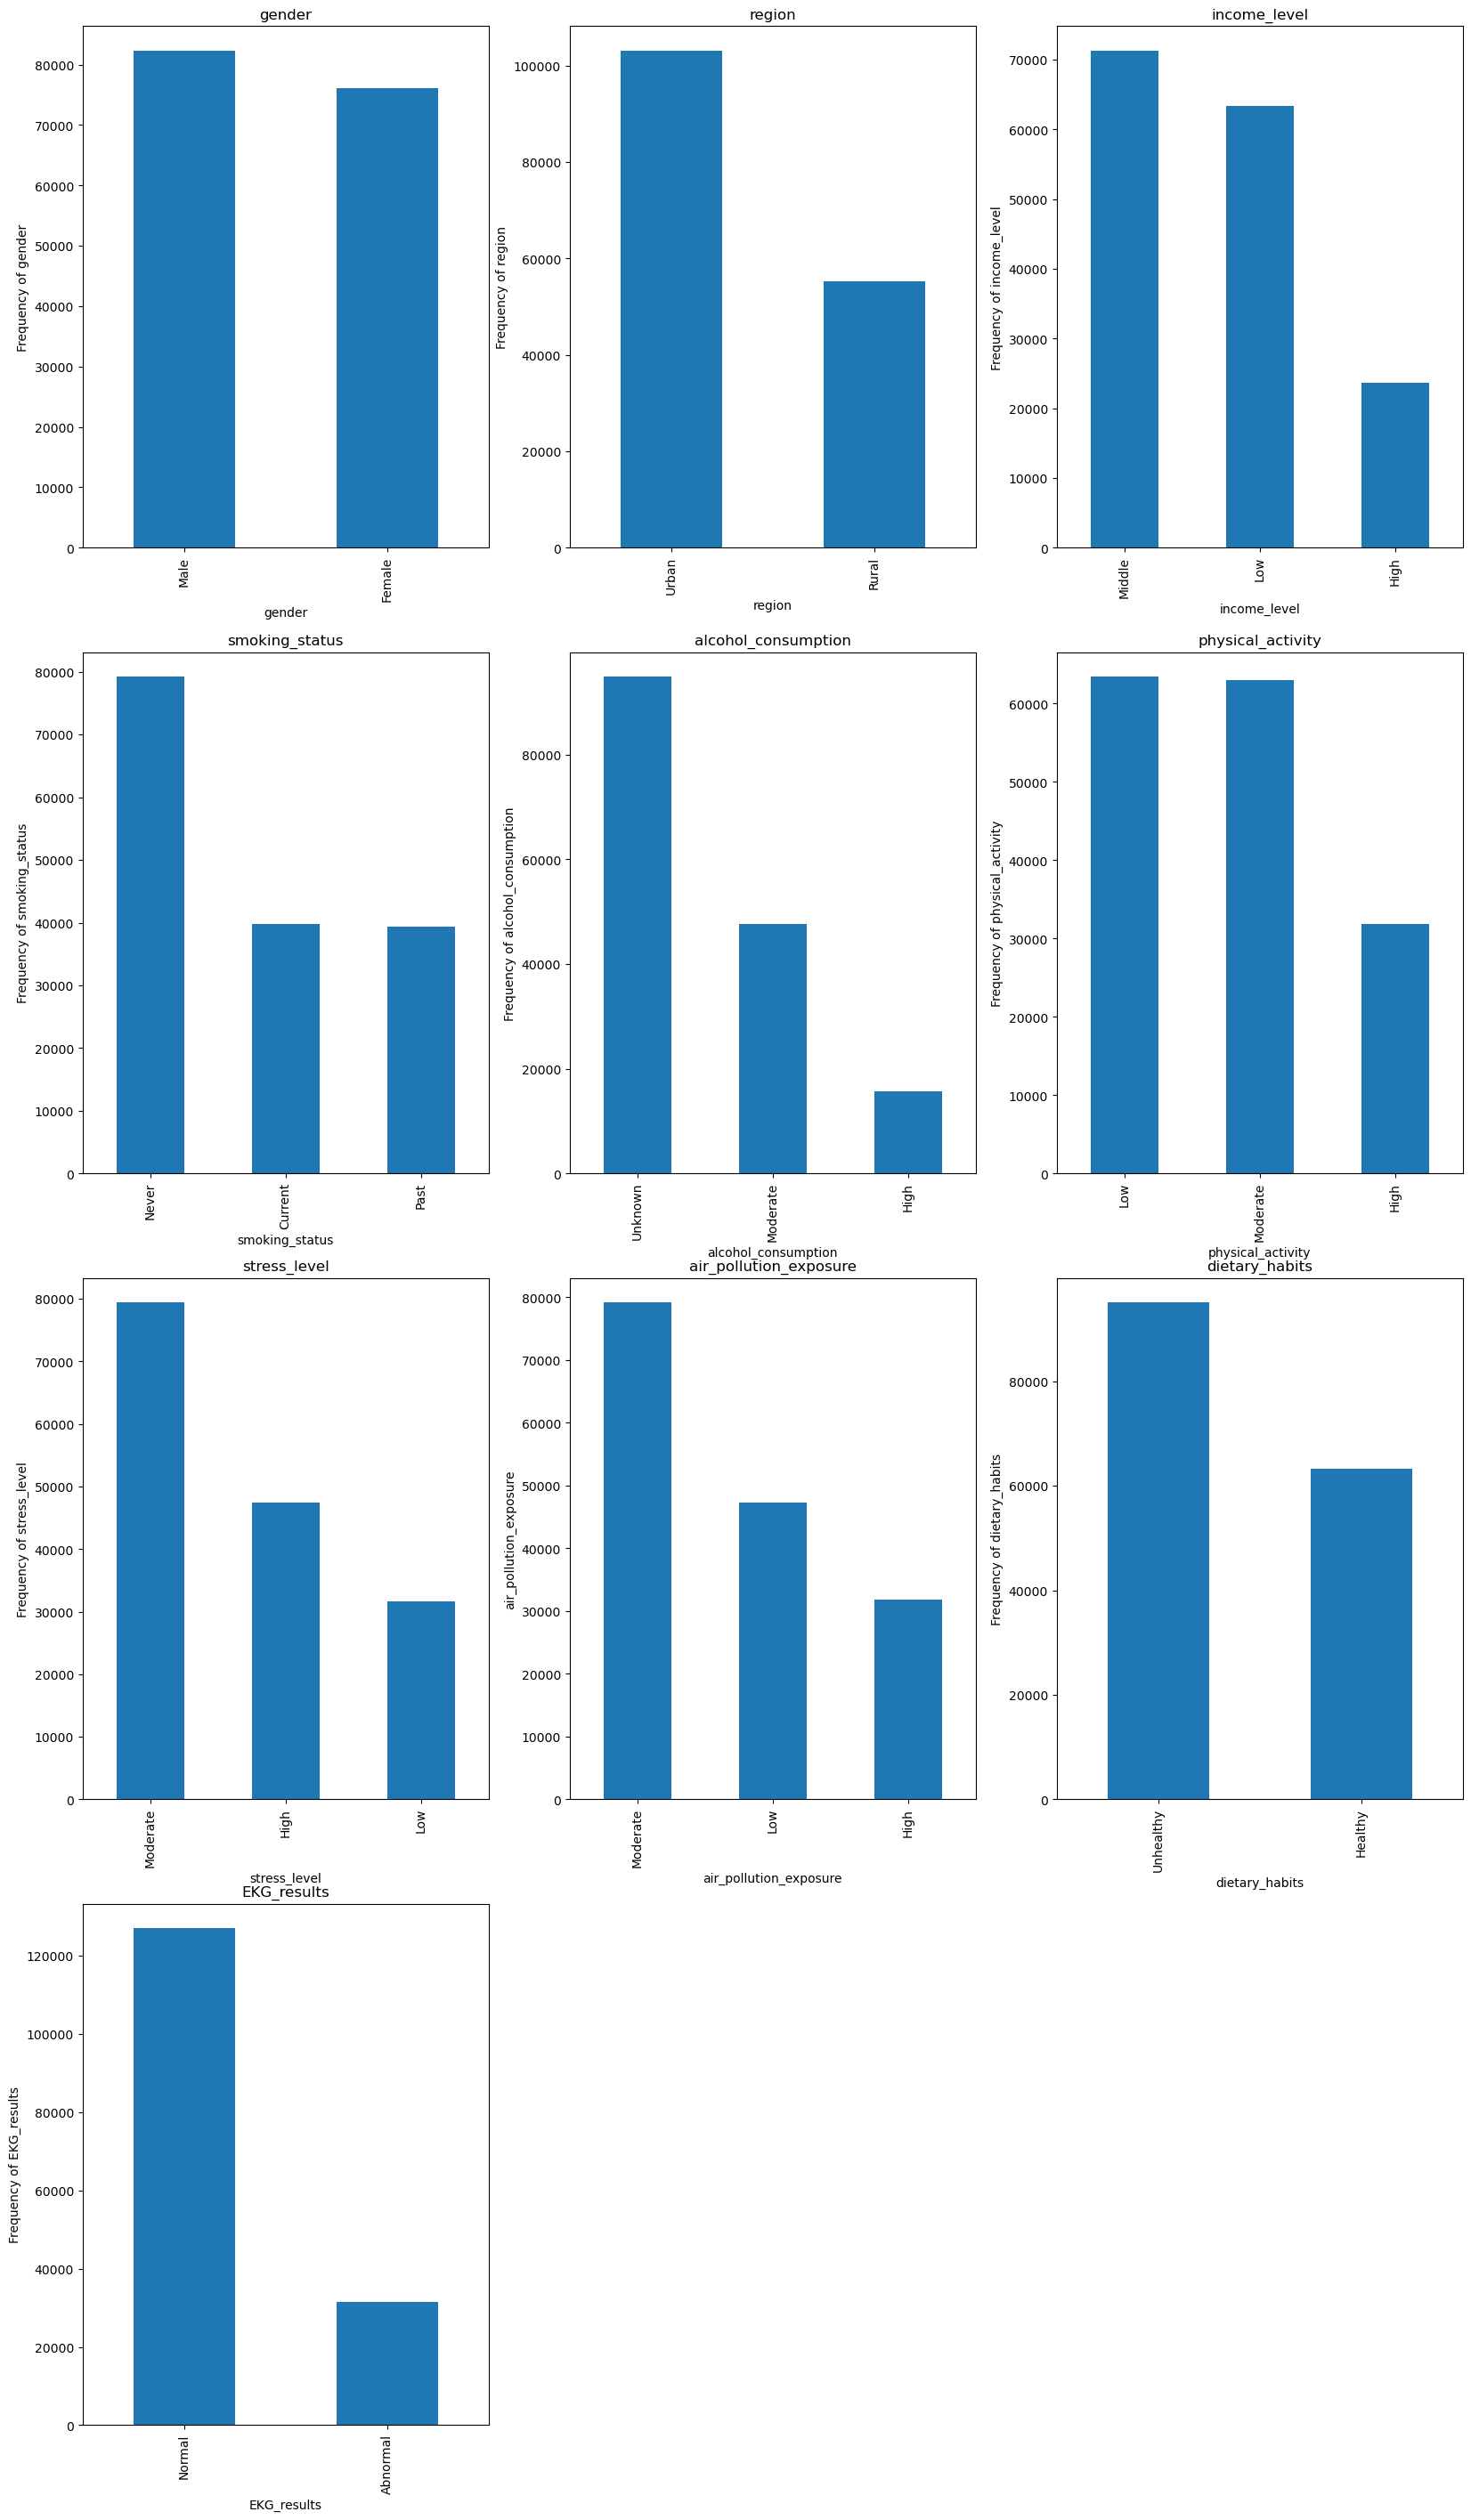

In [55]:
plt.figure(figsize=(20, 35))

plt.subplot(4, 3, 1)
plt1 = data['gender'].value_counts().plot(kind='bar')
plt.title('gender')
plt1.set(xlabel = 'gender', ylabel='Frequency of gender')

plt.subplot(4, 3, 2)
plt1 = data['region'].value_counts().plot(kind='bar')
plt.title('region')
plt1.set(xlabel = 'region', ylabel='Frequency of region')

plt.subplot(4, 3, 3)
plt1 = data['income_level'].value_counts().plot(kind='bar')
plt.title('income_level')
plt1.set(xlabel = 'income_level', ylabel='Frequency of income_level')

plt.subplot(4, 3, 4)
plt1 = data['smoking_status'].value_counts().plot(kind='bar')
plt.title('smoking_status')
plt1.set(xlabel = 'smoking_status', ylabel='Frequency of smoking_status')

plt.subplot(4, 3, 5)
plt1 = data['alcohol_consumption'].value_counts().plot(kind='bar')
plt.title('alcohol_consumption')
plt1.set(xlabel = 'alcohol_consumption', ylabel='Frequency of alcohol_consumption')

plt.subplot(4, 3, 6)
plt1 = data['physical_activity'].value_counts().plot(kind='bar')
plt.title('physical_activity')
plt1.set(xlabel = 'physical_activity', ylabel='Frequency of physical_activity')

plt.subplot(4, 3, 7)
plt1 = data['stress_level'].value_counts().plot(kind='bar')
plt.title('stress_level')
plt1.set(xlabel = 'stress_level', ylabel='Frequency of stress_level')

plt.subplot(4, 3, 8)
plt1 = data['air_pollution_exposure'].value_counts().plot(kind='bar')
plt.title('air_pollution_exposure')
plt1.set(xlabel = 'air_pollution_exposure', ylabel='air_pollution_exposure')

plt.subplot(4, 3, 9)
plt1 = data['dietary_habits'].value_counts().plot(kind='bar')
plt.title('dietary_habits')
plt1.set(xlabel = 'dietary_habits', ylabel='Frequency of dietary_habits')

plt.subplot(4, 3, 10)
plt1 = data['EKG_results'].value_counts().plot(kind='bar')
plt.title('EKG_results')
plt1.set(xlabel = 'EKG_results', ylabel='Frequency of EKG_results')

plt.show()

In [56]:
numerical_features = [x for x in data.columns if data[x].dtype in ('int64','float64')]
print(numerical_features)

['age', 'hypertension', 'diabetes', 'cholesterol_level', 'obesity', 'waist_circumference', 'family_history', 'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl', 'triglycerides', 'previous_heart_disease', 'medication_usage', 'participated_in_free_screening', 'heart_attack']


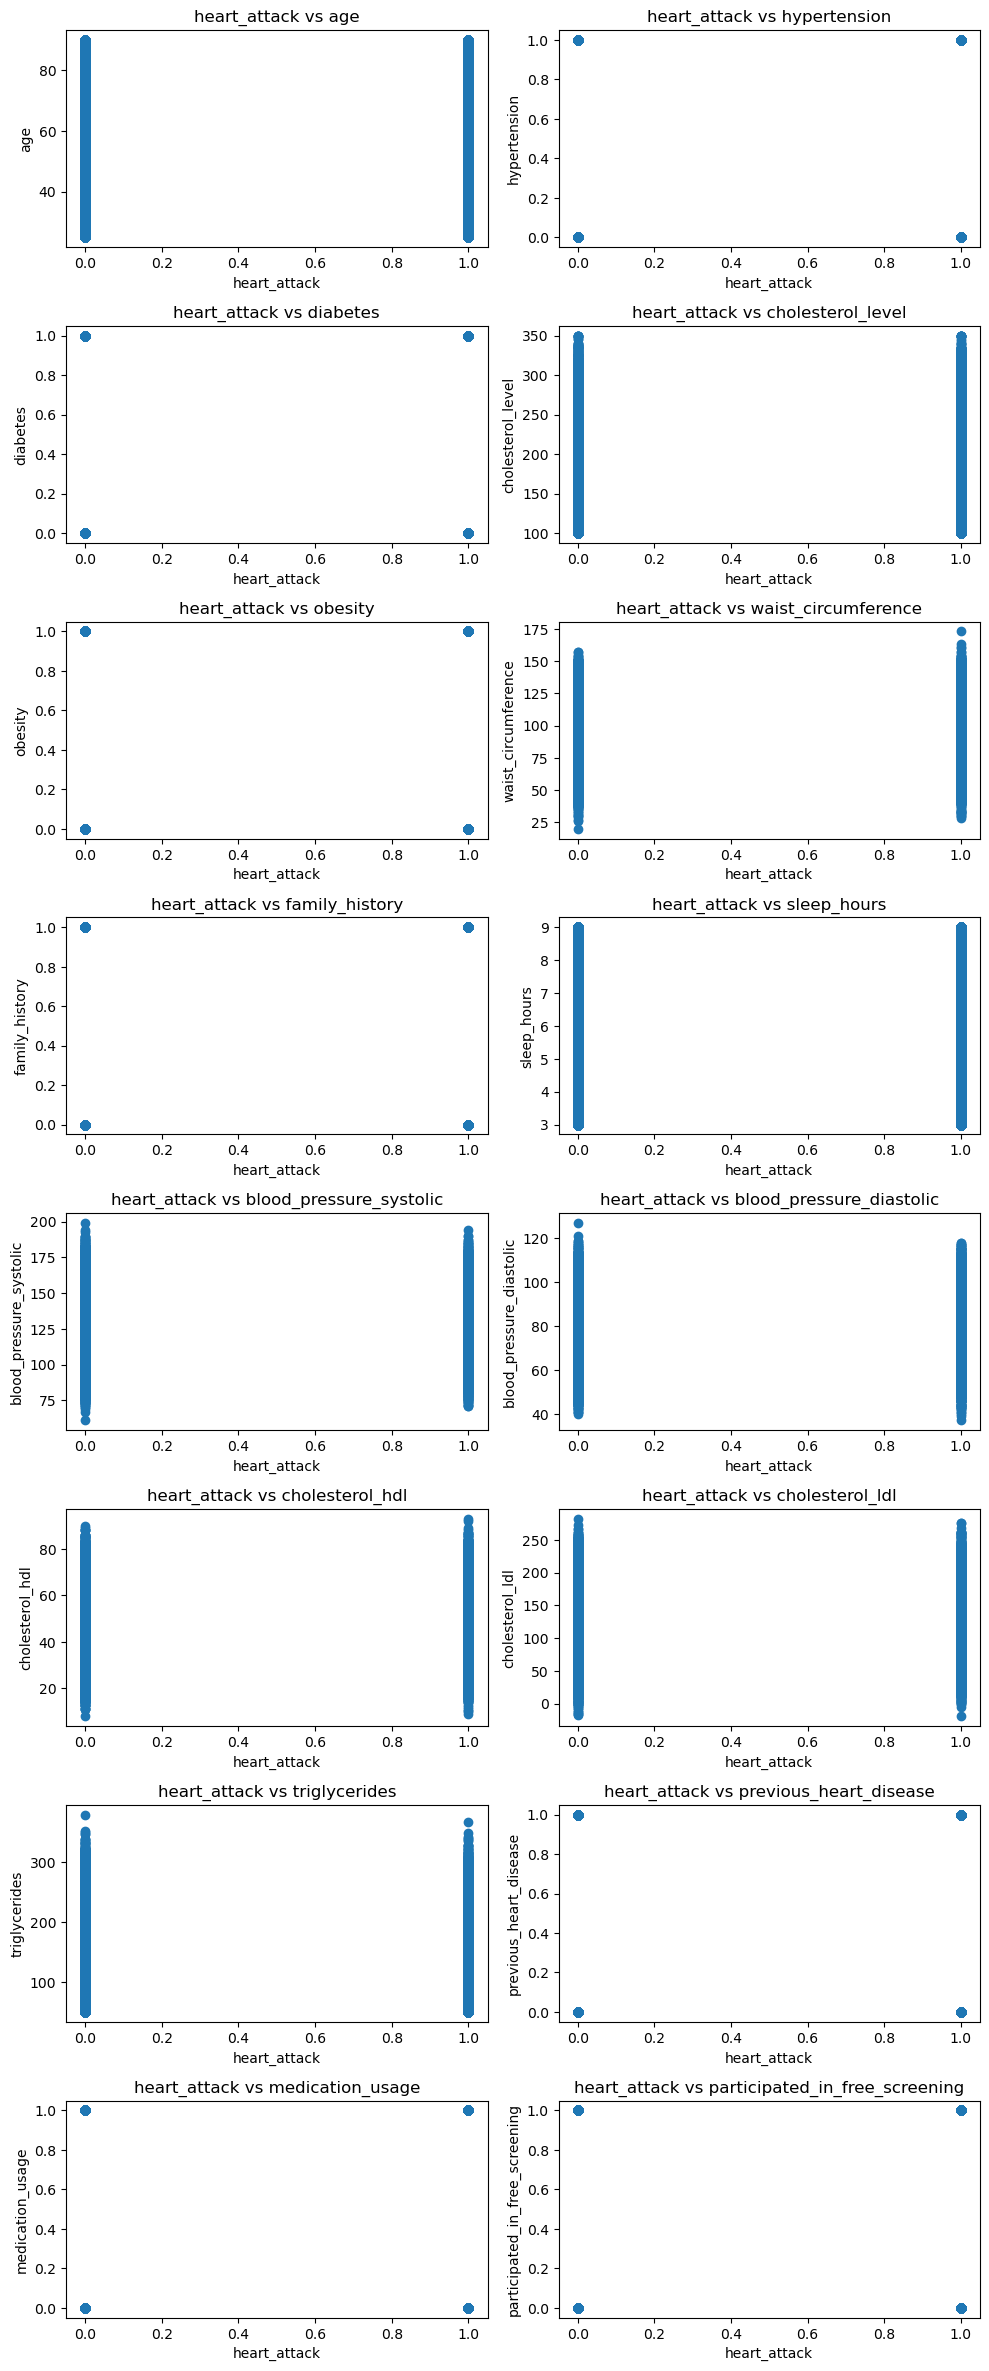

In [57]:
def scatter(y,fig):
    plt.subplot(17,2,fig)
    plt.scatter(data['heart_attack'],data[y])
    plt.title('heart_attack vs '+y)
    plt.ylabel(y)
    plt.xlabel('heart_attack')

plt.figure(figsize=(10,50))

scatter('age', 1)
scatter('hypertension', 2)
scatter('diabetes', 3)
scatter('cholesterol_level', 4)
scatter('obesity',5)
scatter('waist_circumference',6)
scatter('family_history',7)
scatter('sleep_hours',8)
scatter('blood_pressure_systolic',9)
scatter('blood_pressure_diastolic',10)
scatter('cholesterol_hdl',11)
scatter('cholesterol_ldl',12)
scatter('triglycerides',13)
scatter('previous_heart_disease',14)
scatter('medication_usage',15)
scatter('participated_in_free_screening',16)

plt.tight_layout()

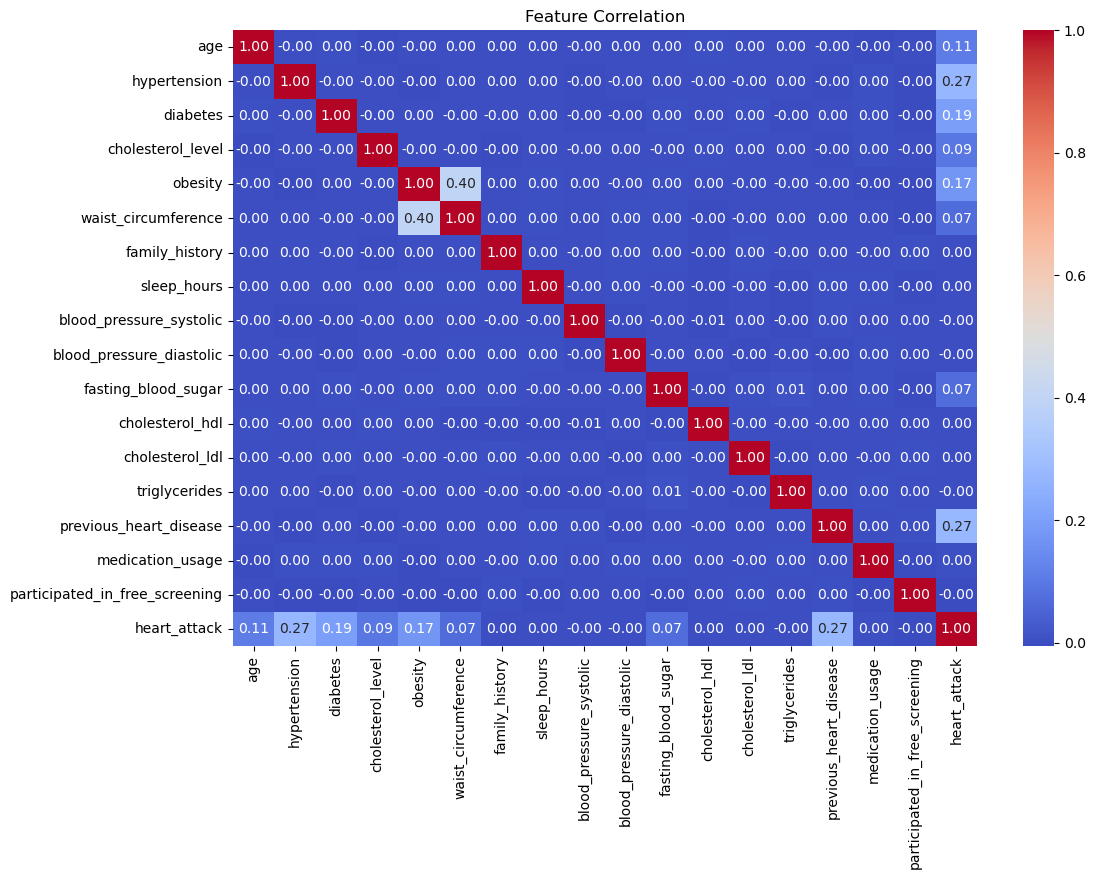

In [58]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()


Feature Selection

In [59]:
categorical_features = [x for x in data.columns if data[x].dtype =='object']
categorical_features

['gender',
 'region',
 'income_level',
 'smoking_status',
 'alcohol_consumption',
 'physical_activity',
 'dietary_habits',
 'air_pollution_exposure',
 'stress_level',
 'EKG_results']

In [60]:
# drop redundant features
data = data.drop(columns = ['region','income_level','air_pollution_exposure','participated_in_free_screening'])
data.head()

,age,gender,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,smoking_status,alcohol_consumption,...,blood_pressure_systolic,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,heart_attack
0,60,Male,0,1,211,0,83,0,Never,Unknown,...,113,62,173,48,121,101,Normal,0,0,0
1,53,Female,0,0,208,0,106,1,Past,Unknown,...,132,76,70,58,83,138,Normal,1,0,0
2,62,Female,0,0,231,1,112,1,Past,Moderate,...,116,74,118,69,130,171,Abnormal,0,1,1
3,73,Male,1,0,202,0,82,1,Never,Moderate,...,136,65,98,52,85,146,Normal,0,1,0
4,52,Male,1,0,232,0,89,0,Current,Moderate,...,127,75,104,59,127,139,Normal,1,0,1


In [61]:
categorical_features = [x for x in data.columns if data[x].dtype =='object']
categorical_features

['gender',
 'smoking_status',
 'alcohol_consumption',
 'physical_activity',
 'dietary_habits',
 'stress_level',
 'EKG_results']

In [62]:
from sklearn.preprocessing import LabelEncoder

features = [
    'gender',
    'smoking_status',
    'alcohol_consumption',
    'physical_activity',
    'dietary_habits',
    'stress_level',
    'EKG_results'
]

# create a LabelEncoder instance
le = LabelEncoder()

# encode each feature column
for col in features:
    data[col] = le.fit_transform(data[col])

data.head()

,age,gender,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,smoking_status,alcohol_consumption,...,blood_pressure_systolic,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,heart_attack
0,60,1,0,1,211,0,83,0,1,2,...,113,62,173,48,121,101,1,0,0,0
1,53,0,0,0,208,0,106,1,2,2,...,132,76,70,58,83,138,1,1,0,0
2,62,0,0,0,231,1,112,1,2,1,...,116,74,118,69,130,171,0,0,1,1
3,73,1,1,0,202,0,82,1,1,1,...,136,65,98,52,85,146,1,0,1,0
4,52,1,1,0,232,0,89,0,0,1,...,127,75,104,59,127,139,1,1,0,1


In [63]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158355 entries, 0 to 158354
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   age                       158355 non-null  int64  
 1   gender                    158355 non-null  int64  
 2   hypertension              158355 non-null  int64  
 3   diabetes                  158355 non-null  int64  
 4   cholesterol_level         158355 non-null  int64  
 5   obesity                   158355 non-null  int64  
 6   waist_circumference       158355 non-null  int64  
 7   family_history            158355 non-null  int64  
 8   smoking_status            158355 non-null  int64  
 9   alcohol_consumption       158355 non-null  int64  
 10  physical_activity         158355 non-null  int64  
 11  dietary_habits            158355 non-null  int64  
 12  stress_level              158355 non-null  int64  
 13  sleep_hours               158355 non-null  f

In [64]:
# Remove outliers
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.01, random_state=42)
yhat = iso.fit_predict(data.drop(columns=["heart_attack"])) 
data["Outlier"] = yhat
data_new = data[data["Outlier"] == 1].drop(columns=["Outlier"])
data.shape[0], data_new.shape[0]

(158355, 156771)

In [65]:
# save cleaned data
data_new.to_csv("/workspaces/Heart-Attack-Predictor/notebooks/FC212041_Isivara/cleaned_heart_attack_risk_dataset.csv", index=False)